# 2 - class weights

0 = Background,
1 = building,
2 = road,
3 = water,
4 = barren,
5 = forest,
6 = agriculture,

In [4]:
import os
import numpy as np
np.set_printoptions(formatter={'float_kind':'{:f}'.format})

In [ ]:
example_mask = np.load('/home/giordano_vitale/ETE-Thesis-2024-ML-002/LoveDA/train/masks/0.npy')
example_mask = np.argmax(example_mask, axis=-1)
example_mask

In [11]:
class_pixel_counts = np.zeros(7)
masks_path = '/home/giordano_vitale/ETE-Thesis-2024-ML-002/LoveDA/train/masks/'

for mask in os.listdir(masks_path):
    if mask.endswith('.npy'):
        mask = np.load(os.path.join(masks_path, mask))
        class_pixel_counts += np.sum(mask, axis=(0,1))

In [23]:
class_pixel_counts

array([1010342082.000000, 281492898.000000, 134119728.000000,
       162729435.000000, 132748561.000000, 409074865.000000,
       514001103.000000])

In [17]:
num_pixels = np.sum(class_pixel_counts)
num_pixels

2644508672.0

In [18]:
class_weights = num_pixels / (7*class_pixel_counts)

<Axes: >

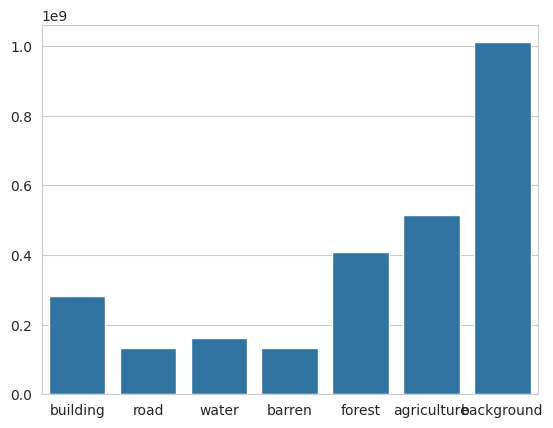

In [1]:
import seaborn as sns
# add label names
class_pixel_counts = [281492898.000000, 134119728.000000,
       162729435.000000, 132748561.000000, 409074865.000000,
       514001103.000000, 1010342082.000000]
sns.set_style("whitegrid")
class_names = ['building', 'road', 'water', 'barren', 'forest', 'agriculture', 'background'] 
sns.barplot(x=class_names, y=class_pixel_counts)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))
sns.heatmap(cmatrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 4 visualize mask vs. prediction

In [14]:
import tensorflow as tf
import sys
sys.path.append('Code/')
from dataset_loader import *
from custom_loss import *
from Code.dataset_loader import DatasetCreator, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
import cv2
BATCH_SIZE = 4

In [15]:
def reverse_preprocess_input(img):
    """
    Reverse the preprocessing applied by keras.applications.resnet50.preprocess_input.
    
    Args:
    img: Preprocessed image (with 3 channels, values subtracted by ImageNet mean).
    
    Returns:
    Reversed image in the range [0, 255].
    """

    img = img.astype(np.float64)
    # Reverse the mean subtraction
    img[..., 0] += 103.939  # Add back the ImageNet mean for the R channel
    img[..., 1] += 116.779  # Add back the ImageNet mean for the G channel
    img[..., 2] += 123.68   # Add back the ImageNet mean for the B channel

    # Clip the values to ensure they are within valid pixel range
    img = np.clip(img, 0, 255)

    return img.astype(np.uint8)

In [16]:
from custom_loss import foc_tversky, paper_loss_function

## Image vs. Mask vs. Prediction

In [17]:
model = tf.keras.models.load_model('Models_saved/DeepLabV3Plus/Experiment_Number_6.keras', compile=False)

In [18]:
x_valid_dir = 'LoveDA/val/img/'
y_valid_dir = 'LoveDA/val/masks/'

val_dataset = DatasetCreator(x_valid_dir, y_valid_dir, training=False, size=(512,512),
                             preprocessing=tf.keras.applications.resnet.preprocess_input)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [19]:
image, mask = val_dataloader.__getitem__(10)
predictions = model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [20]:
paper_loss_function(mask, predictions)

<tf.Tensor: shape=(), dtype=float32, numpy=1.2312436>

Mean IoU for image 0: 0.10


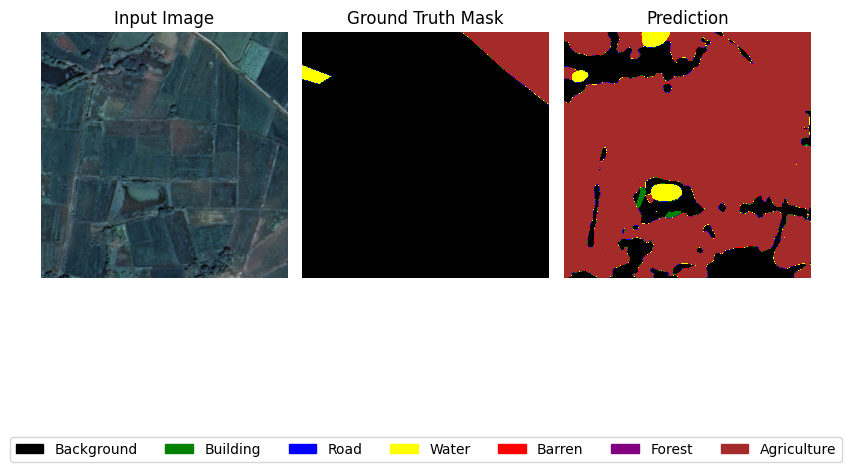

In [24]:
cmap = ListedColormap(['black', 'green', 'blue', 'yellow', 'red', 'purple', 'brown'])
class_names = ['Background', 'Building', 'Road', 'Water', 'Barren', 'Forest', 'Agriculture']

def plot_images_masks_predictions(image, mask, prediction, index):
    fig, axes = plt.subplots(1, 3, figsize=(8, 5))
    
    # Plot input image
    axes[0].imshow(reverse_preprocess_input(image[index]))
    axes[0].set_title('Input Image')
    axes[0].axis('off')
    
    # Plot ground truth mask
    axes[1].imshow(np.argmax(mask[index], axis=-1), cmap=cmap, vmin=0, vmax=len(class_names)-1)
    axes[1].set_title('Ground Truth Mask')
    axes[1].axis('off')
    
    # Plot prediction
    pred_mask = np.argmax(prediction[index], axis=-1)
    axes[2].imshow(pred_mask, cmap=cmap, vmin=0, vmax=len(class_names)-1)
    axes[2].set_title('Prediction')
    axes[2].axis('off')
    
    legend_patches = [mpatches.Patch(color=cmap(i), label=class_names[i]) for i in range(len(class_names))]
    fig.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=7)
    
    from tensorflow.keras.metrics import OneHotMeanIoU
    metric = OneHotMeanIoU(num_classes=7)
    metric.update_state(y_true=mask[index], y_pred=predictions[index])
    print(f"Mean IoU for image {index}: {metric.result().numpy():.2f}")

    plt.tight_layout()
    plt.show()

plot_images_masks_predictions(image, mask, predictions, index=0)

Compute the OneHotMeanIoU for this specific batch.

In [13]:
from tensorflow.keras.metrics import OneHotMeanIoU
metric = OneHotMeanIoU(num_classes=7)
metric.update_state(y_true=mask, y_pred=predictions)
print(f"IoU for this specific batch is: {metric.result().numpy()}")

IoU for this specific batch is: 0.47672438621520996


# 5 - Confusion matrix

In [1]:
import sys
sys.path.append('Code/')
from dataset_loader import *
from helpers import compute_confusion_matrix
x_val_dir = 'LoveDA/val/img/'
y_val_dir = 'LoveDA/val/masks/'

val_dataset = DatasetCreator(x_val_dir, y_val_dir, training=False, size=(512,512),
                             preprocessing=tf.keras.applications.resnet.preprocess_input)
val_dataloader = DataLoader(val_dataset, batch_size=2, shuffle=False)


model = tf.keras.models.load_model('Models_saved/DeepLabV3Plus/Experiment_Number_6.keras',
                                   compile=False)

conf_matrix = compute_confusion_matrix(model, val_dataloader)

2024-11-07 14:23:25.892102: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-07 14:23:26.357381: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-07 14:23:26.542461: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-07 14:23:26.590230: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-07 14:23:26.940951: I tensorflow/core/platform/cpu_feature_guar

1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step


I0000 00:00:1730985840.518906 1562764 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━

: 

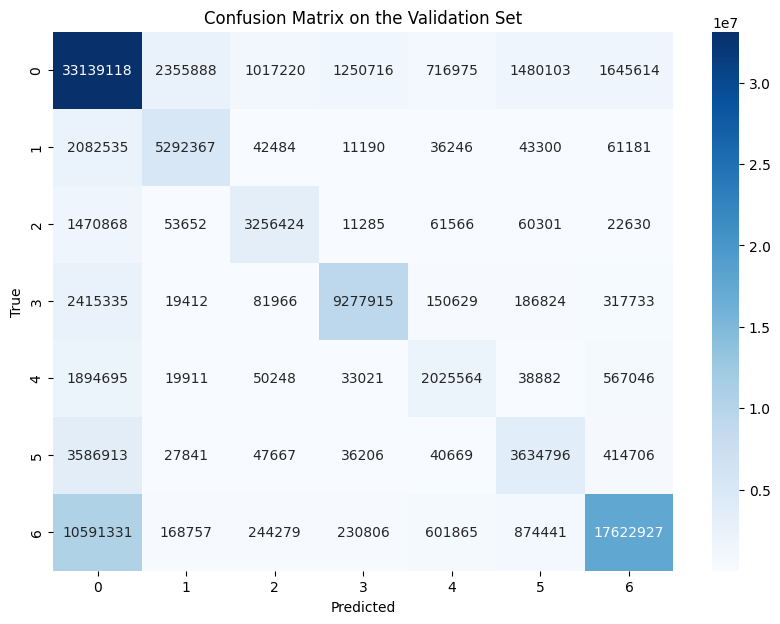

In [ ]:
import seaborn as sns
plt.figure(figsize=(10,7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.title('Confusion Matrix on the Validation Set')
plt.show()

# 6 - Batch Visualization

In [14]:
x_valid_dir = 'LoveDA/val/img/'
y_valid_dir = 'LoveDA/val/masks/'

val_dataset = DatasetCreator(x_valid_dir, y_valid_dir, training=False, size=(256,256),
                               preprocessing=tf.keras.applications.resnet.preprocess_input)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [15]:
model = tf.keras.models.load_model('Models_saved/TransferLearning/ResNet50-UNet/Experiment_Number_18.keras', compile=False)

In [16]:
image, mask = val_dataloader.__getitem__(0)
predictions = model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


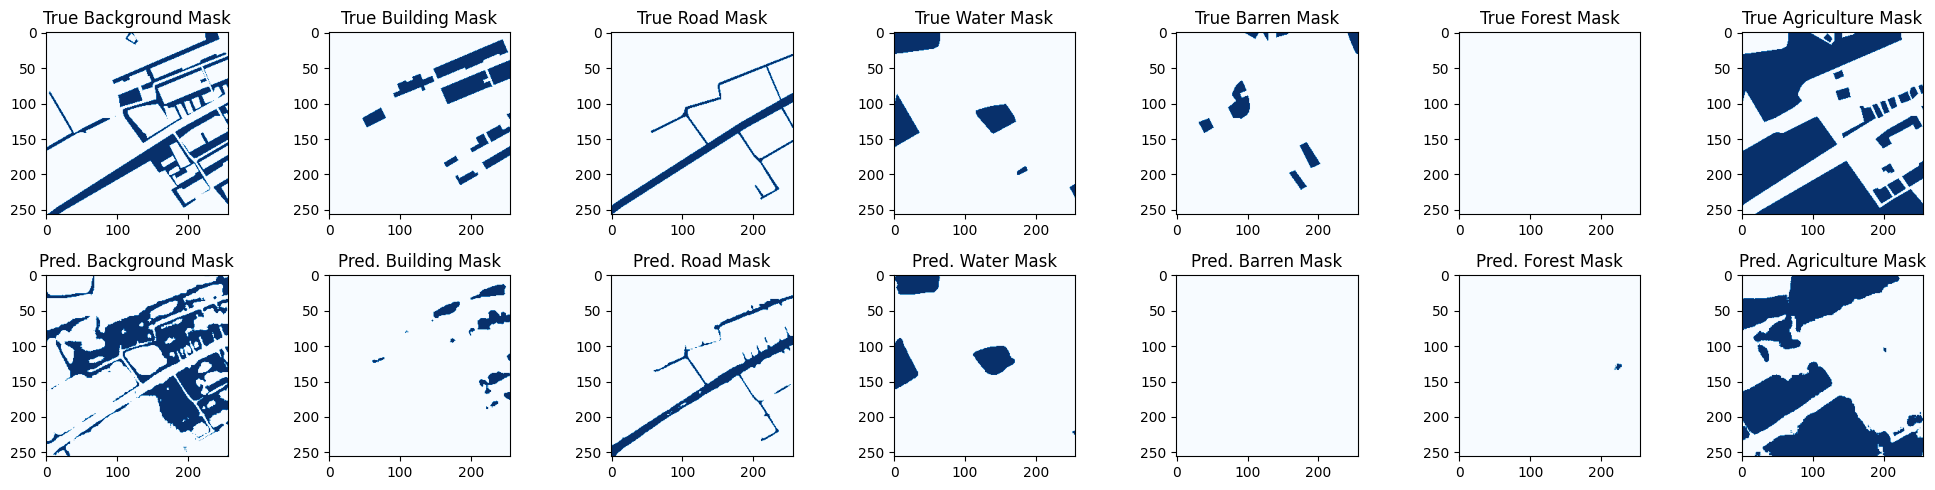

In [44]:
import matplotlib.pyplot as plt
import numpy as np

def plot_images_masks_predictions(mask, predictions, index, cmap):
    fig, axes = plt.subplots(2, 7, figsize=(20, 5))
    
    # True masks
    axes[0, 0].imshow(mask[index][:, :, 0], cmap=cmap)
    axes[0, 0].set_title('True Background Mask')

    axes[0, 1].imshow(mask[index][:, :, 1], cmap=cmap)
    axes[0, 1].set_title('True Building Mask')

    axes[0, 2].imshow(mask[index][:, :, 2], cmap=cmap)
    axes[0, 2].set_title('True Road Mask')

    axes[0, 3].imshow(mask[index][:, :, 3], cmap=cmap)
    axes[0, 3].set_title('True Water Mask')

    axes[0, 4].imshow(mask[index][:, :, 4], cmap=cmap)
    axes[0, 4].set_title('True Barren Mask')

    axes[0, 5].imshow(mask[index][:, :, 5], cmap=cmap)
    axes[0, 5].set_title('True Forest Mask')

    axes[0, 6].imshow(mask[index][:, :, 6], cmap=cmap)
    axes[0, 6].set_title('True Agriculture Mask')

    # Threshold predictions
    thresholded_predictions = (predictions > 0.5).astype(np.uint8)

    # Predicted masks
    axes[1, 0].imshow(thresholded_predictions[index][:, :, 0], cmap=cmap)
    axes[1, 0].set_title('Pred. Background Mask')

    axes[1, 1].imshow(thresholded_predictions[index][:, :, 1], cmap=cmap)
    axes[1, 1].set_title('Pred. Building Mask')

    axes[1, 2].imshow(thresholded_predictions[index][:, :, 2], cmap=cmap)
    axes[1, 2].set_title('Pred. Road Mask')

    axes[1, 3].imshow(thresholded_predictions[index][:, :, 3], cmap=cmap)
    axes[1, 3].set_title('Pred. Water Mask')

    axes[1, 4].imshow(thresholded_predictions[index][:, :, 4], cmap=cmap)
    axes[1, 4].set_title('Pred. Barren Mask')

    axes[1, 5].imshow(thresholded_predictions[index][:, :, 5], cmap=cmap)
    axes[1, 5].set_title('Pred. Forest Mask')

    axes[1, 6].imshow(thresholded_predictions[index][:, :, 6], cmap=cmap)
    axes[1, 6].set_title('Pred. Agriculture Mask')

    fig.tight_layout()

# Example usage
plot_images_masks_predictions(mask, predictions, index=0, cmap='Blues')

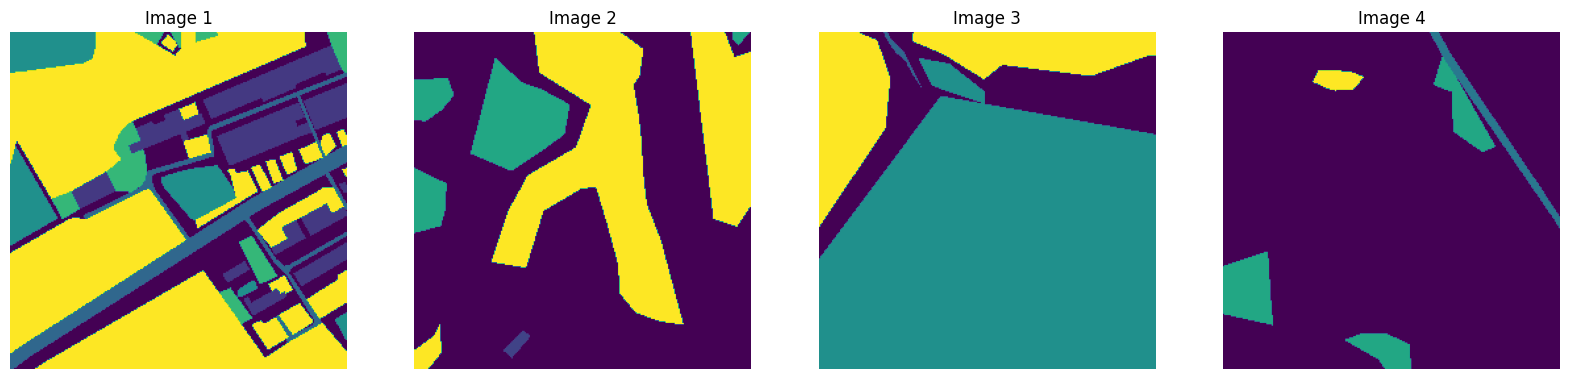

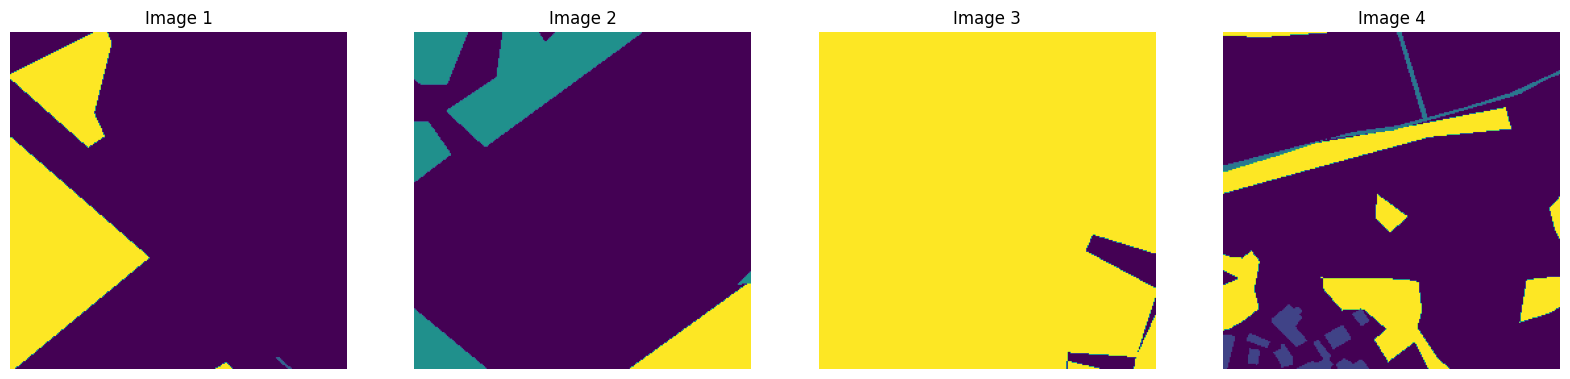

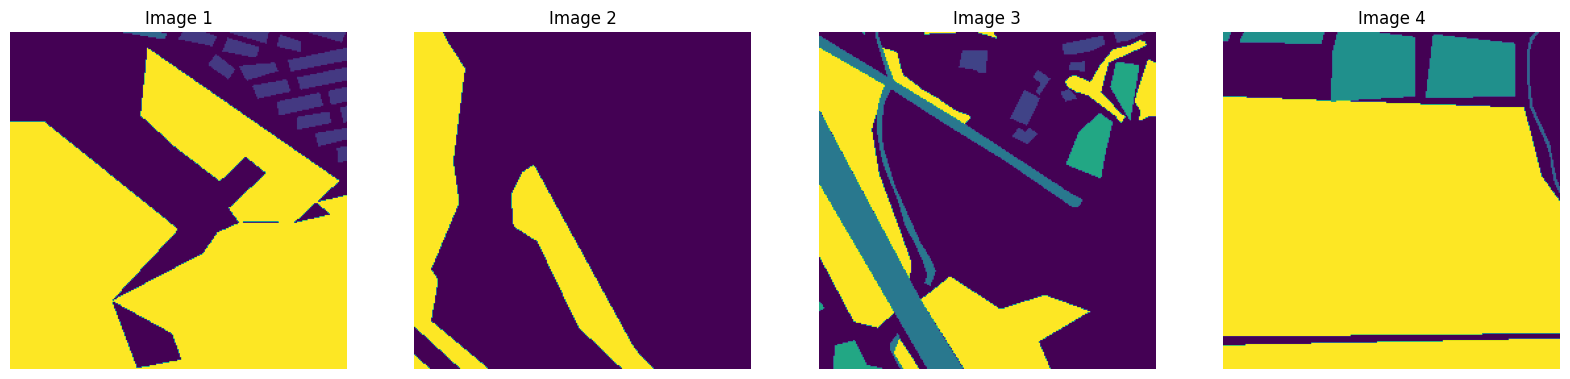

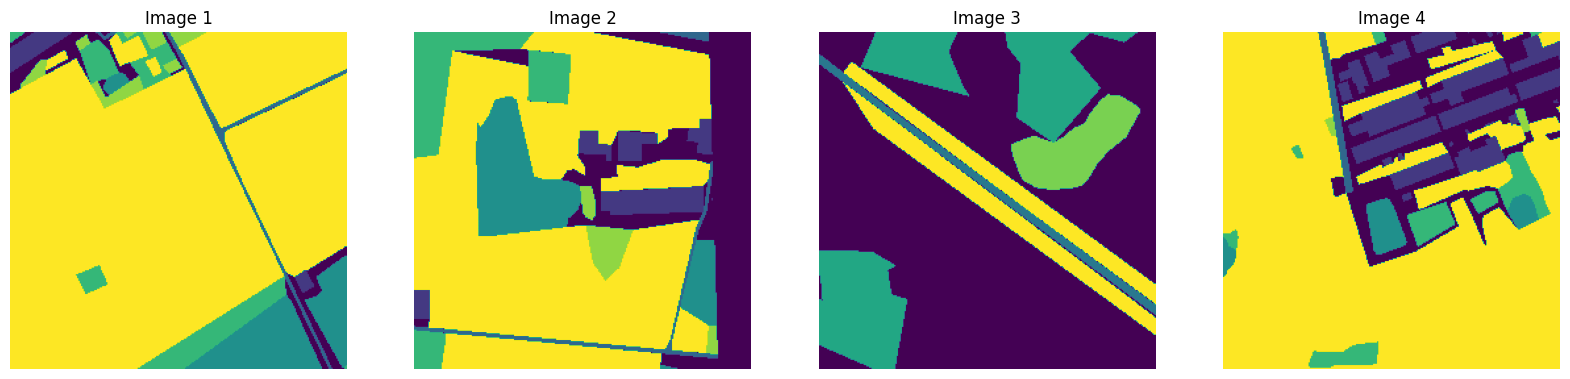

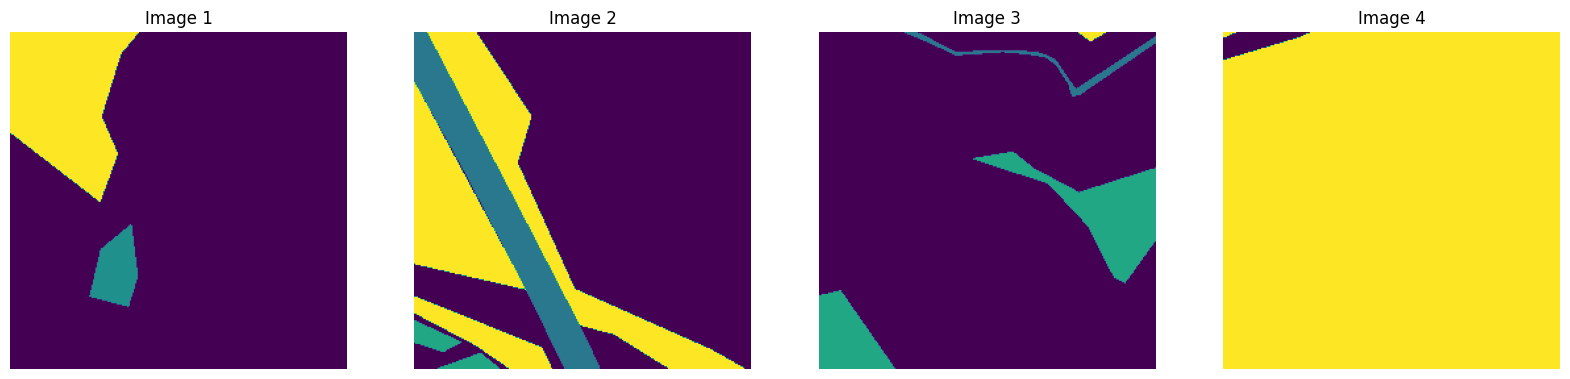

In [50]:
import matplotlib.pyplot as plt

x_valid_dir = 'LoveDA/val/img/'
y_valid_dir = 'LoveDA/val/masks/'

val_dataset = DatasetCreator(x_valid_dir, y_valid_dir, training=False, size=(256,256),
                               preprocessing=tf.keras.applications.resnet.preprocess_input)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Visualize the batch
def visualize_batch(images, batch_size, is_mask=False):
    plt.figure(figsize=(20, 10))
    for i in range(batch_size):
        # Display image
        plt.subplot(2, batch_size, i + 1)
        
        if is_mask:
            pred_mask = np.argmax(images[i], axis=-1)
            plt.imshow(pred_mask)
        else:
            plt.imshow(reverse_preprocess_input(images[i]))
        plt.title(f'Image {i+1}')
        plt.axis('off')
    plt.show()


for i in range(5):
    batch_images, batch_masks = val_dataloader.__getitem__(i)
    visualize_batch(batch_masks, batch_size=4, is_mask=True)

# 7 - Binary Forest

In [ ]:
import tensorflow as tf
import sys
sys.path.append('Code/')
from dataset_loader import *
from custom_loss import *
from Code.dataset_loader import DatasetCreator, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
import cv2
BATCH_SIZE = 4

In [2]:
def reverse_preprocess_input(img):
    """
    Reverse the preprocessing applied by keras.applications.resnet50.preprocess_input.
    
    Args:
    img: Preprocessed image (with 3 channels, values subtracted by ImageNet mean).
    
    Returns:
    Reversed image in the range [0, 255].
    """

    img = img.astype(np.float64)
    # Reverse the mean subtraction
    img[..., 0] += 103.939  # Add back the ImageNet mean for the R channel
    img[..., 1] += 116.779  # Add back the ImageNet mean for the G channel
    img[..., 2] += 123.68   # Add back the ImageNet mean for the B channel

    # Clip the values to ensure they are within valid pixel range
    img = np.clip(img, 0, 255)

    return img.astype(np.uint8)

Text(0.5, 1.0, 'Ground Truth Mask')

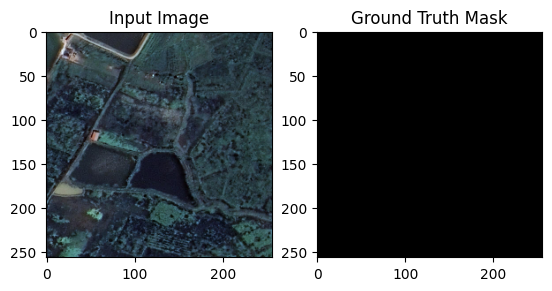

In [73]:
x_valid_dir_forest = 'Binary_Forest/val/img/'
y_valid_dir_forest = 'Binary_Forest/val/masks/'

val_dataset_forest = DatasetCreator(x_valid_dir_forest, y_valid_dir_forest, training=False, size=(256,256),
                               preprocessing=tf.keras.applications.resnet.preprocess_input)
val_dataloader_forest = DataLoader(val_dataset_forest, batch_size=BATCH_SIZE, shuffle=False)

image_forest, mask_forest = val_dataloader_forest.__getitem__(26)

plt.subplot(1, 2, 1)
plt.imshow(reverse_preprocess_input(image_forest[3]))
plt.title('Input Image')

plt.subplot(1, 2, 2)
plt.imshow(mask_forest[3][:, :, 1], cmap='gray')
plt.title('Ground Truth Mask')

In [16]:
model = tf.keras.models.load_model('Models_saved/Forest/Experiment_Number_1.keras', compile=False)

In [46]:
predictions = model.predict(image_forest)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [68]:
from tensorflow.keras.losses import categorical_crossentropy

tf.reduce_mean(categorical_crossentropy(mask_forest, predictions)[0])

<tf.Tensor: shape=(), dtype=float32, numpy=0.036559485>

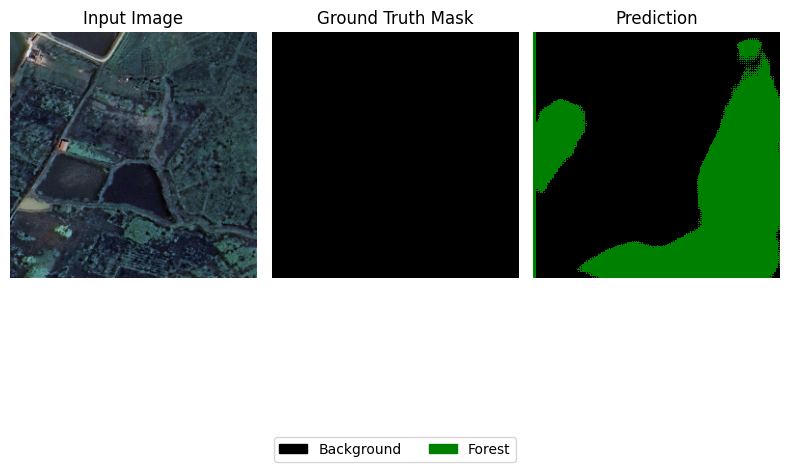

In [45]:
cmap = ListedColormap(['black', 'green'])
class_names = ['Background', 'Forest']

def plot_images_masks_predictions(image, mask, prediction, index):
    fig, axes = plt.subplots(1, 3, figsize=(8, 5))
    
    # Plot input image
    axes[0].imshow(reverse_preprocess_input(image[index]))
    axes[0].set_title('Input Image')
    axes[0].axis('off')
    
    # Plot ground   truth mask
    axes[1].imshow(np.argmax(mask[index], axis=-1), cmap=cmap, vmin=0, vmax=len(class_names)-1)
    axes[1].set_title('Ground Truth Mask')
    axes[1].axis('off')
    
    # Plot prediction
    pred_mask = np.argmax(prediction[index], axis=-1)
    axes[2].imshow(reverse_preprocess_input(pred_mask), cmap=cmap, vmin=0, vmax=len(class_names)-1)
    axes[2].set_title('Prediction')
    axes[2].axis('off')
    
    legend_patches = [mpatches.Patch(color=cmap(i), label=class_names[i]) for i in range(len(class_names))]
    fig.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=7)
    
    plt.tight_layout()
    plt.show()

plot_images_masks_predictions(image=image_forest, mask=mask_forest, prediction=predictions, index=3)

In [7]:
import sys
sys.path.append('Forest_Modelling/')
from loss_forest import weighted_ce_forest

In [58]:
weighted_ce_forest(mask_forest, predictions).numpy()

0.098683245

# 8 - Models assessment

### Plot

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing import event_accumulator

# Paths to the training and validation log directories
train_log_dir = "Logs/DeepLabV3Plus/Experiment_Number_6/train"
val_log_dir = "Logs/DeepLabV3Plus/Experiment_Number_6/validation"

# Load event files for training and validation separately
train_event_acc = event_accumulator.EventAccumulator(train_log_dir)
val_event_acc = event_accumulator.EventAccumulator(val_log_dir)

# Reload the events
train_event_acc.Reload()
val_event_acc.Reload()

# List available tags to confirm metrics
print("Training Tags:", train_event_acc.Tags())
print("Validation Tags:", val_event_acc.Tags())

Training Tags: {'images': [], 'audio': [], 'histograms': [], 'scalars': [], 'distributions': [], 'tensors': ['keras', 'epoch_iou_agriculture', 'epoch_iou_background', 'epoch_iou_barren', 'epoch_iou_building', 'epoch_iou_forest', 'epoch_iou_road', 'epoch_iou_water', 'epoch_loss', 'epoch_mean_iou', 'epoch_learning_rate', 'kernel/histogram', 'bias/histogram', 'gamma/histogram', 'beta/histogram', 'moving_mean/histogram', 'moving_variance/histogram'], 'graph': True, 'meta_graph': False, 'run_metadata': []}
Validation Tags: {'images': [], 'audio': [], 'histograms': [], 'scalars': [], 'distributions': [], 'tensors': ['evaluation_iou_agriculture_vs_iterations', 'evaluation_iou_background_vs_iterations', 'evaluation_iou_barren_vs_iterations', 'evaluation_iou_building_vs_iterations', 'evaluation_iou_forest_vs_iterations', 'evaluation_iou_road_vs_iterations', 'evaluation_iou_water_vs_iterations', 'evaluation_loss_vs_iterations', 'evaluation_mean_iou_vs_iterations', 'epoch_iou_agriculture', 'epoch

In [5]:
# Retrieve metrics from tensor tags for training
train_loss = train_event_acc.Tensors("epoch_loss")
train_iou = train_event_acc.Tensors("epoch_mean_iou")

# Retrieve metrics from tensor tags for validation
val_loss = val_event_acc.Tensors("epoch_loss")
val_iou = val_event_acc.Tensors("epoch_mean_iou")

In [16]:
# Extract the values and steps
train_loss_values = [tf.make_ndarray(event.tensor_proto).item() for event in train_loss]
train_iou_values = [tf.make_ndarray(event.tensor_proto).item() for event in train_iou]
val_loss_values = [tf.make_ndarray(event.tensor_proto).item() for event in val_loss]
val_iou_values = [tf.make_ndarray(event.tensor_proto).item() for event in val_iou]

# Assuming steps correspond to epochs (or adjust as needed)
epochs = [event.step for event in train_loss]

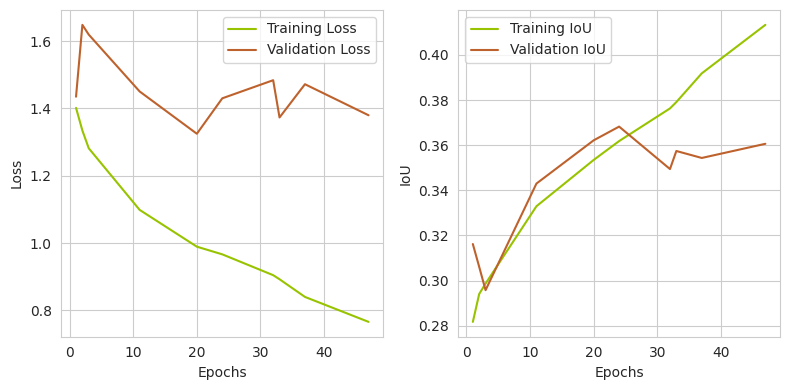

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Plot Loss
axes[0].plot(epochs, train_loss_values, label="Training Loss", color='#98c300')
axes[0].plot(epochs, val_loss_values, label="Validation Loss", color='#be622d')
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
# axes[0].set_title("Training and Validation Loss over Epochs")
axes[0].legend()

# Plot IoU
axes[1].plot(epochs, train_iou_values, label="Training IoU", color='#98c300')
axes[1].plot(epochs, val_iou_values, label="Validation IoU", color='#be622d')
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("IoU")
# axes[1].set_title("Training and Validation IoU over Epochs")
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
print(len(epochs), len(train_loss_values), len(val_loss_values), len(train_iou_values), len(val_iou_values))

10 10 10 10 10


### Single class

In [6]:
train_background_iou = train_event_acc.Tensors("epoch_iou_background")
train_building_iou = train_event_acc.Tensors("epoch_iou_building")
train_road_iou = train_event_acc.Tensors("epoch_iou_road")
train_water_iou = train_event_acc.Tensors("epoch_iou_water")
train_barren_iou = train_event_acc.Tensors("epoch_iou_barren")
train_forest_iou = train_event_acc.Tensors("epoch_iou_forest")
train_agriculture_iou = train_event_acc.Tensors("epoch_iou_agriculture")

val_background_iou = val_event_acc.Tensors("epoch_iou_background")
val_building_iou = val_event_acc.Tensors("epoch_iou_building")
val_road_iou = val_event_acc.Tensors("epoch_iou_road")
val_water_iou = val_event_acc.Tensors("epoch_iou_water")
val_barren_iou = val_event_acc.Tensors("epoch_iou_barren")
val_forest_iou = val_event_acc.Tensors("epoch_iou_forest")
val_agriculture_iou = val_event_acc.Tensors("epoch_iou_agriculture")

# Extract values for each IoU metric
train_background_iou_values = [tf.make_ndarray(event.tensor_proto).item() for event in train_background_iou]
train_building_iou_values = [tf.make_ndarray(event.tensor_proto).item() for event in train_building_iou]
train_road_iou_values = [tf.make_ndarray(event.tensor_proto).item() for event in train_road_iou]
train_water_iou_values = [tf.make_ndarray(event.tensor_proto).item() for event in train_water_iou]
train_barren_iou_values = [tf.make_ndarray(event.tensor_proto).item() for event in train_barren_iou]
train_forest_iou_values = [tf.make_ndarray(event.tensor_proto).item() for event in train_forest_iou]
train_agriculture_iou_values = [tf.make_ndarray(event.tensor_proto).item() for event in train_agriculture_iou]

val_background_iou_values = [tf.make_ndarray(event.tensor_proto).item() for event in val_background_iou]
val_building_iou_values = [tf.make_ndarray(event.tensor_proto).item() for event in val_building_iou]
val_road_iou_values = [tf.make_ndarray(event.tensor_proto).item() for event in val_road_iou]
val_water_iou_values = [tf.make_ndarray(event.tensor_proto).item() for event in val_water_iou]
val_barren_iou_values = [tf.make_ndarray(event.tensor_proto).item() for event in val_barren_iou]
val_forest_iou_values = [tf.make_ndarray(event.tensor_proto).item() for event in val_forest_iou]
val_agriculture_iou_values = [tf.make_ndarray(event.tensor_proto).item() for event in val_agriculture_iou]

/tmp/ipykernel_659466/143998722.py:56: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  fig.legend([f1, f2, f3, f4, f5, f6], labels=['training', 'validation'], loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=1)


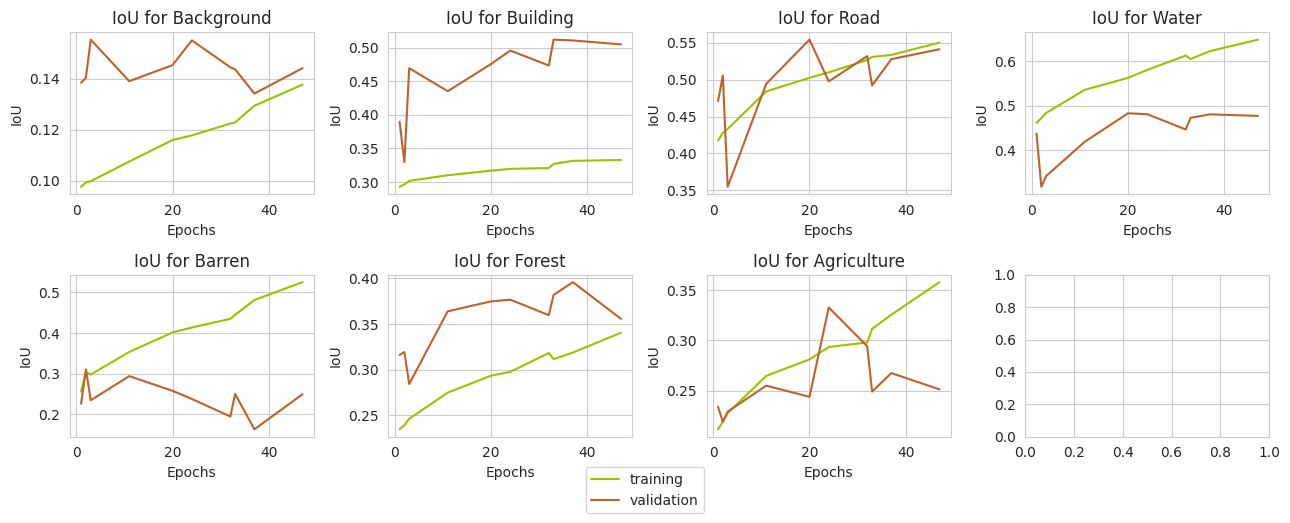

In [7]:
import matplotlib.pyplot as plt

# Assuming `epochs` has been defined as the list of steps for each epoch
fig, axes = plt.subplots(2, 4, figsize=(13, 5))

axes = axes.flatten()
# Background
f1 = axes[0].plot(epochs, train_background_iou_values, label="Training IoU Background", color='#98c300')
f1 = axes[0].plot(epochs, val_background_iou_values, label="Validation IoU Background", color='#be622d')
f1 = axes[0].set_xlabel("Epochs")
f1 = axes[0].set_ylabel("IoU")
f1 = axes[0].set_title("IoU for Background")

# Building
f2 = axes[1].plot(epochs, train_building_iou_values, label="Training IoU Building", color='#98c300')
f2 = axes[1].plot(epochs, val_building_iou_values, label="Validation IoU building", color='#be622d')
f2 = axes[1].set_xlabel("Epochs")
f2 = axes[1].set_ylabel("IoU")
f2 = axes[1].set_title("IoU for Building")

# Road
f2 = axes[2].plot(epochs, train_road_iou_values, label="Training IoU Road", color='#98c300')
f2 = axes[2].plot(epochs, val_road_iou_values, label="Validation IoU Road", color='#be622d')
f2 = axes[2].set_xlabel("Epochs")
f2 = axes[2].set_ylabel("IoU")
f2 = axes[2].set_title("IoU for Road")

# Water
f3 = axes[3].plot(epochs, train_water_iou_values, label="Training IoU Water", color='#98c300')
f3 = axes[3].plot(epochs, val_water_iou_values, label="Validation IoU Water", color='#be622d')
f3 = axes[3].set_xlabel("Epochs")
f3 = axes[3].set_ylabel("IoU")
f3 = axes[3].set_title("IoU for Water")

# Barren
f4 = axes[4].plot(epochs, train_barren_iou_values, label="Training IoU Barren", color='#98c300')
f4 = axes[4].plot(epochs, val_barren_iou_values, label="Validation IoU Barren", color='#be622d')
f4 = axes[4].set_xlabel("Epochs")
f4 = axes[4].set_ylabel("IoU")
f4 = axes[4].set_title("IoU for Barren")

# Forest
f5 = axes[5].plot(epochs, train_forest_iou_values, label="Training IoU Forest", color='#98c300')
f5 = axes[5].plot(epochs, val_forest_iou_values, label="Validation IoU Forest", color='#be622d')
f5 = axes[5].set_xlabel("Epochs")
f5 = axes[5].set_ylabel("IoU")
f5 = axes[5].set_title("IoU for Forest")

# Agriculture
f6 = axes[6].plot(epochs, train_agriculture_iou_values, label="Training IoU Agriculture", color='#98c300')
f6 = axes[6].plot(epochs, val_agriculture_iou_values, label="Validation IoU Agriculture", color='#be622d')
f6 = axes[6].set_xlabel("Epochs")
f6 = axes[6].set_ylabel("IoU")
f6 = axes[6].set_title("IoU for Agriculture")

fig.legend([f1, f2, f3, f4, f5, f6], labels=['training', 'validation'], loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=1)
plt.tight_layout()
plt.show()

### From CSV Data

In [73]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
sys.path.append('Results-CSV/')

Preprocess the csv.

In [66]:
modell = 'AttentionUNet'

In [70]:
train_loss = pd.read_csv(f'Results-CSV/{modell}/Loss/train.csv')
val_loss = pd.read_csv(f'Results-CSV/{modell}/Loss/validation.csv')

train_iou = pd.read_csv(f'Results-CSV/{modell}/IoU/train.csv')
val_iou = pd.read_csv(f'Results-CSV/{modell}/IoU/validation.csv')

In [71]:
train_iou['Value'] = train_iou['Value'] + 0.06
val_iou['Value'] = val_iou['Value'] + 0.04

Plot.

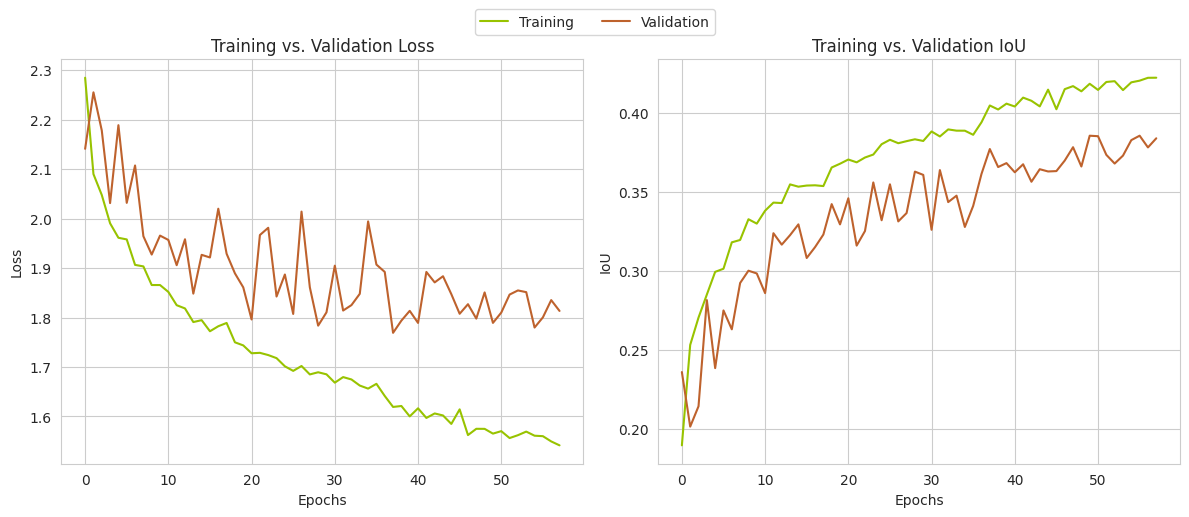

In [72]:
# Loss 
epochs = train_loss['Step']
train_loss_values = train_loss['Value']
val_loss_values = val_loss['Value']

# IoU values
train_iou_values = train_iou['Value']
val_iou_values = val_iou['Value']

# Create subplots
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Loss
axes[0].plot(epochs, train_loss_values, label="Training", color='#98c300')
axes[0].plot(epochs, val_loss_values, label="Validation", color='#be622d')
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training vs. Validation Loss")

# Plot IoU
axes[1].plot(epochs, train_iou_values, color='#98c300')
axes[1].plot(epochs, val_iou_values, color='#be622d')
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("IoU")
axes[1].set_title("Training vs. Validation IoU")

# Set the legend in the middle of the two plots, with two lines and one column representing the colors
fig.legend(loc='center', bbox_to_anchor=(0.5, 1.0), ncol=2)

plt.tight_layout()

# Set the number of floats in the y axis to be 2
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

plt.show()

In [52]:
val_loss['Value'].min()

1.3053946495056152

/tmp/ipykernel_712089/3116853679.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  f1 = axes[0].set_yticklabels(['0.25', '0.30', '0.35', '0.40'])
/tmp/ipykernel_712089/3116853679.py:51: UserWarning: FixedFormatter should only be used together with FixedLocator
  f2 = axes[1].set_yticklabels(['0.15', '0.20', '0.25', '0.30', '0.35'])
/tmp/ipykernel_712089/3116853679.py:66: UserWarning: FixedFormatter should only be used together with FixedLocator
  f3 = axes[3].set_yticklabels(['0.30', '0.35', '0.40', '0.45', '0.50'])
/tmp/ipykernel_712089/3116853679.py:89: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  fig.legend([f1, f2, f3, f4, f5, f6], labels=['training', 'validation'], loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=1)


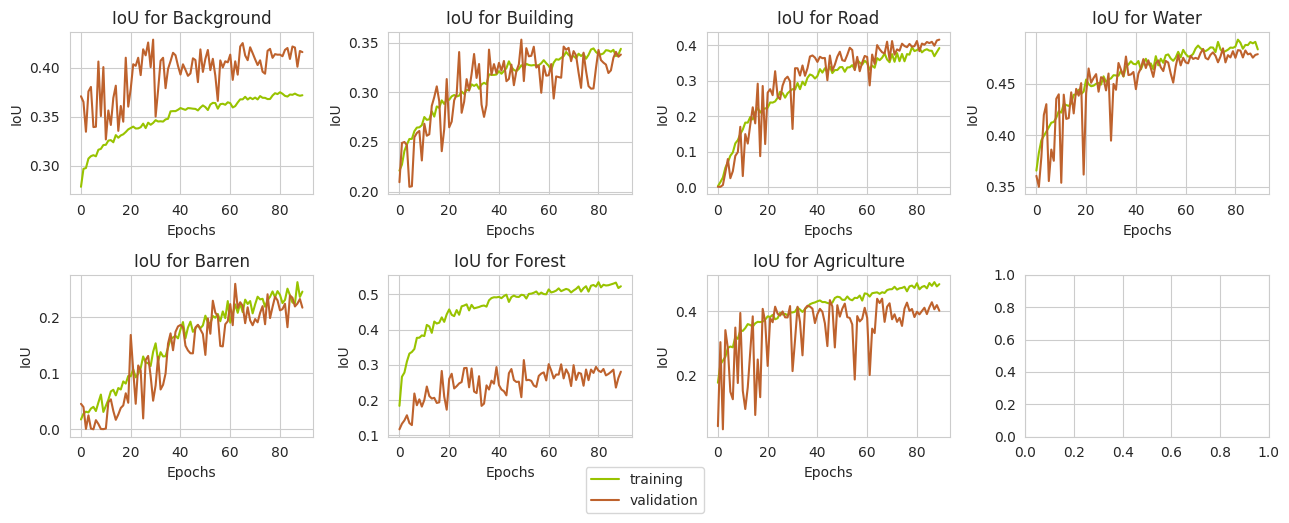

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Background
train_background = pd.read_csv('Results-CSV/UNet-ExperimentNumber3/Background/train.csv')
val_background = pd.read_csv('Results-CSV/UNet-ExperimentNumber3/Background/validation.csv')
epochs = train_background['Step']

# Building
train_building = pd.read_csv('Results-CSV/UNet-ExperimentNumber3/Building/train.csv')
val_building = pd.read_csv('Results-CSV/UNet-ExperimentNumber3/Building/validation.csv')

# Road
train_road = pd.read_csv('Results-CSV/UNet-ExperimentNumber3/Road/train.csv')
val_road = pd.read_csv('Results-CSV/UNet-ExperimentNumber3/Road/validation.csv')

# Water
train_water = pd.read_csv('Results-CSV/UNet-ExperimentNumber3/Water/train.csv')
val_water = pd.read_csv('Results-CSV/UNet-ExperimentNumber3/Water/validation.csv')

# Barren
train_barren = pd.read_csv('Results-CSV/UNet-ExperimentNumber3/Barren/train.csv')
val_barren = pd.read_csv('Results-CSV/UNet-ExperimentNumber3/Barren/validation.csv')

# Forest
train_forest = pd.read_csv('Results-CSV/UNet-ExperimentNumber3/Forest/train.csv')
val_forest = pd.read_csv('Results-CSV/UNet-ExperimentNumber3/Forest/validation.csv')

# Agriculture
train_agriculture = pd.read_csv('Results-CSV/UNet-ExperimentNumber3/Agriculture/train.csv')
val_agriculture = pd.read_csv('Results-CSV/UNet-ExperimentNumber3/Agriculture/validation.csv')


fig, axes = plt.subplots(2, 4, figsize=(13, 5))

axes = axes.flatten()
# Background
f1 = axes[0].plot(epochs, train_background['Value'], label="Training IoU Background", color='#98c300')
f1 = axes[0].plot(epochs, val_background['Value'], label="Validation IoU Background", color='#be622d')
f1 = axes[0].set_xlabel("Epochs")
f1 = axes[0].set_ylabel("IoU")
f1 = axes[0].set_title("IoU for Background")
f1 = axes[0].set_yticklabels(['0.25', '0.30', '0.35', '0.40'])

# Building
f2 = axes[1].plot(epochs, train_building['Value'], label="Training IoU Building", color='#98c300')
f2 = axes[1].plot(epochs, val_building['Value'], label="Validation IoU building", color='#be622d')
f2 = axes[1].set_xlabel("Epochs")
f2 = axes[1].set_ylabel("IoU")
f2 = axes[1].set_title("IoU for Building")
f2 = axes[1].set_yticklabels(['0.15', '0.20', '0.25', '0.30', '0.35'])

# Road
f2 = axes[2].plot(epochs, train_road['Value'], label="Training IoU Road", color='#98c300')
f2 = axes[2].plot(epochs, val_road['Value'], label="Validation IoU Road", color='#be622d')
f2 = axes[2].set_xlabel("Epochs")
f2 = axes[2].set_ylabel("IoU")
f2 = axes[2].set_title("IoU for Road")

# Water
f3 = axes[3].plot(epochs, train_water['Value'], label="Training IoU Water", color='#98c300')
f3 = axes[3].plot(epochs, val_water['Value'], label="Validation IoU Water", color='#be622d')
f3 = axes[3].set_xlabel("Epochs")
f3 = axes[3].set_ylabel("IoU")
f3 = axes[3].set_title("IoU for Water")
f3 = axes[3].set_yticklabels(['0.30', '0.35', '0.40', '0.45', '0.50'])

# Barren
f4 = axes[4].plot(epochs, train_barren['Value'], label="Training IoU Barren", color='#98c300')
f4 = axes[4].plot(epochs, val_barren['Value'], label="Validation IoU Barren", color='#be622d')
f4 = axes[4].set_xlabel("Epochs")
f4 = axes[4].set_ylabel("IoU")
f4 = axes[4].set_title("IoU for Barren")

# Forest
f5 = axes[5].plot(epochs, train_forest['Value'], label="Training IoU Forest", color='#98c300')
f5 = axes[5].plot(epochs, val_forest['Value'], label="Validation IoU Forest", color='#be622d')
f5 = axes[5].set_xlabel("Epochs")
f5 = axes[5].set_ylabel("IoU")
f5 = axes[5].set_title("IoU for Forest")

# Agriculture
f6 = axes[6].plot(epochs, train_agriculture['Value'], label="Training IoU Agriculture", color='#98c300')
f6 = axes[6].plot(epochs, val_agriculture['Value'], label="Validation IoU Agriculture", color='#be622d')
f6 = axes[6].set_xlabel("Epochs")
f6 = axes[6].set_ylabel("IoU")
f6 = axes[6].set_title("IoU for Agriculture")

fig.legend([f1, f2, f3, f4, f5, f6], labels=['training', 'validation'], loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=1)
plt.tight_layout()
plt.show()

### Comparison

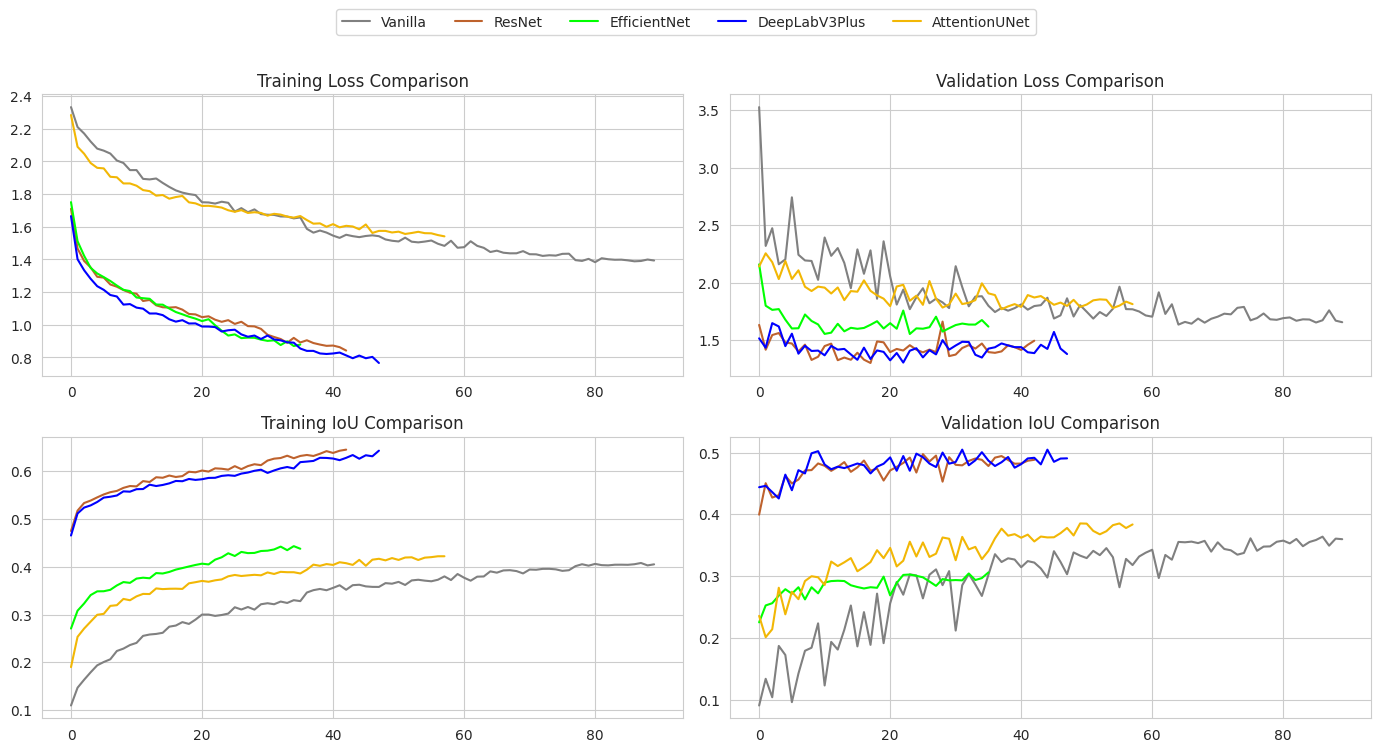

In [103]:
# Vanilla UNet
vanilla_train_loss = pd.read_csv('Results-CSV/UNet-ExperimentNumber3/Loss/train.csv')
vanilla_val_loss = pd.read_csv(f'Results-CSV/UNet-ExperimentNumber3/Loss/validation.csv')

vanilla_train_iou = pd.read_csv(f'Results-CSV/UNet-ExperimentNumber3/IoU/train.csv')
vanilla_val_iou = pd.read_csv(f'Results-CSV/UNet-ExperimentNumber3/IoU/validation.csv')

# ResNet50-UNet
resnet_train_loss = pd.read_csv('Results-CSV/ResNet50UNet-ExperimentNumber35/Loss/train.csv')
resnet_val_loss = pd.read_csv(f'Results-CSV/ResNet50UNet-ExperimentNumber35/Loss/validation.csv')

resnet_train_iou = pd.read_csv(f'Results-CSV/ResNet50UNet-ExperimentNumber35/IoU/train.csv')
resnet_train_iou['Value'] = resnet_train_iou['Value'] + 0.25
resnet_val_iou = pd.read_csv(f'Results-CSV/ResNet50UNet-ExperimentNumber35/IoU/validation.csv')
resnet_val_iou['Value'] = resnet_val_iou['Value'] + 0.12

# EfficientNetB0-UNet
efficientnet_train_loss = pd.read_csv('Results-CSV/UNet-EfficientNet/Loss/train.csv')
efficientnet_val_loss = pd.read_csv(f'Results-CSV/UNet-EfficientNet/Loss/validation.csv')
efficientnet_val_loss['Value'] = efficientnet_val_loss['Value'] + 0.23

efficientnet_train_iou = pd.read_csv(f'Results-CSV/UNet-EfficientNet/IoU/train.csv')
efficientnet_train_iou['Value'] = efficientnet_train_iou['Value'] + 0.05
efficientnet_val_iou = pd.read_csv(f'Results-CSV/UNet-EfficientNet/IoU/validation.csv')
efficientnet_val_iou['Value'] = efficientnet_val_iou['Value'] - 0.06

# DeepLabV3Plus
deeplab_train_loss = pd.read_csv('Results-CSV/DeepLabV3Plus-ExperimentNumber6/Loss/train.csv')
deeplab_val_loss = pd.read_csv(f'Results-CSV/DeepLabV3Plus-ExperimentNumber6/Loss/validation.csv')

deeplab_train_iou = pd.read_csv(f'Results-CSV/DeepLabV3Plus-ExperimentNumber6/IoU/train.csv')
deeplab_train_iou['Value'] = deeplab_train_iou['Value'] + 0.23
deeplab_val_iou = pd.read_csv(f'Results-CSV/DeepLabV3Plus-ExperimentNumber6/IoU/validation.csv')
deeplab_val_iou['Value'] = deeplab_val_iou['Value'] + 0.13

# Attention UNet
attention_train_loss = pd.read_csv('Results-CSV/AttentionUNet/Loss/train.csv')
attention_val_loss = pd.read_csv(f'Results-CSV/AttentionUNet/Loss/validation.csv')

attention_train_iou = pd.read_csv(f'Results-CSV/AttentionUNet/IoU/train.csv')
attention_train_iou['Value'] = attention_train_iou['Value'] + 0.06
attention_val_iou = pd.read_csv(f'Results-CSV/AttentionUNet/IoU/validation.csv')
attention_val_iou['Value'] = attention_val_iou['Value'] + 0.04


# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
sns.set_style("whitegrid")

axes = axes.ravel()

# Plot Training Loss
axes[0].plot(vanilla_train_loss['Step'], vanilla_train_loss['Value'], label="Vanilla", color='grey')
axes[0].plot(resnet_train_iou['Step'], resnet_train_loss['Value'], label="ResNet", color='#be622d')
axes[0].plot(efficientnet_train_loss['Step'], efficientnet_train_loss['Value'], label="EfficientNet", color='#00FF00')
axes[0].plot(deeplab_train_loss['Step'], deeplab_train_loss['Value'], label="DeepLabV3Plus", color='#0000FF')
axes[0].plot(attention_train_loss['Step'], attention_train_loss['Value'], label="AttentionUNet", color='#f2b705')
axes[0].set_title("Training Loss Comparison")

# Plot Validation Loss
axes[1].plot(vanilla_val_loss['Step'], vanilla_val_loss['Value'], color='grey')
axes[1].plot(resnet_val_loss['Step'], resnet_val_loss['Value'], color='#be622d')
axes[1].plot(efficientnet_val_loss['Step'], efficientnet_val_loss['Value'], color='#00FF00')
axes[1].plot(deeplab_val_loss['Step'], deeplab_val_loss['Value'], color='#0000FF')
axes[1].plot(attention_val_loss['Step'], attention_val_loss['Value'], color='#f2b705')
axes[1].set_title("Validation Loss Comparison")

# Plot Training IoU
axes[2].plot(vanilla_train_iou['Step'], vanilla_train_iou['Value'], color='grey')
axes[2].plot(resnet_train_iou['Step'], resnet_train_iou['Value'], color='#be622d')
axes[2].plot(efficientnet_train_iou['Step'], efficientnet_train_iou['Value'], color='#00FF00')
axes[2].plot(deeplab_train_iou['Step'], deeplab_train_iou['Value'], color='#0000FF')
axes[2].plot(attention_train_iou['Step'], attention_train_iou['Value'], color='#f2b705')
axes[2].set_title("Training IoU Comparison")

# Plot Validation IoU
axes[3].plot(vanilla_val_iou['Step'], vanilla_val_iou['Value'], color='grey')
axes[3].plot(resnet_val_iou['Step'], resnet_val_iou['Value'], color='#be622d')
axes[3].plot(efficientnet_val_iou['Step'], efficientnet_val_iou['Value'], color='#00FF00')
axes[3].plot(deeplab_val_iou['Step'], deeplab_val_iou['Value'], color='#0000FF')
axes[3].plot(attention_val_iou['Step'], attention_val_iou['Value'], color='#f2b705')
axes[3].set_title("Validation IoU Comparison")

# Set the legend in the middle of the two plots, with two lines and one column representing the colors
fig.legend(loc='center', bbox_to_anchor=(0.5, 1.05), ncol=5)

plt.tight_layout()

# Set the number of floats in the y axis to be 2
#axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

plt.show()

### Masks comparison

In [1]:
import tensorflow as tf
import sys
sys.path.append('Code/')
from dataset_loader import *
from custom_loss import *
from Code.dataset_loader import DatasetCreator, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
import cv2
BATCH_SIZE = 4

2024-11-15 15:45:43.731007: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-15 15:45:43.806796: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-15 15:45:43.841900: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-15 15:45:43.853245: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-15 15:45:43.913006: I tensorflow/core/platform/cpu_feature_guar

In [2]:
def reverse_preprocess_input(img):
    """
    Reverse the preprocessing applied by keras.applications.resnet50.preprocess_input.
    
    Args:
    img: Preprocessed image (with 3 channels, values subtracted by ImageNet mean).
    
    Returns:
    Reversed image in the range [0, 255].
    """

    img = img.astype(np.float64)
    # Reverse the mean subtraction
    img[..., 0] += 103.939  # Add back the ImageNet mean for the R channel
    img[..., 1] += 116.779  # Add back the ImageNet mean for the G channel
    img[..., 2] += 123.68   # Add back the ImageNet mean for the B channel

    # Clip the values to ensure they are within valid pixel range
    img = np.clip(img, 0, 255)

    return img.astype(np.uint8)

Load the models

In [3]:
vanilla_unet = tf.keras.models.load_model('Models_saved/UNet/Experiment_Number_3.keras', compile=False)
resnet_unet = tf.keras.models.load_model('Models_saved/TransferLearning/ResNet50-UNet/Experiment_Number_35.keras', compile=False)
efficientnet_unet = tf.keras.models.load_model('Models_saved/TransferLearning/EfficientNetB5-UNet/Experiment_Number_33.keras', compile=False)
deeplab = tf.keras.models.load_model('Models_saved/DeepLabV3Plus/Experiment_Number_6.keras', compile=False)
attention_unet = tf.keras.models.load_model('Models_saved/AttentionUNet/ResNet50-UNet/Experiment_Number_6.keras', compile=False)

I0000 00:00:1731681953.646706  287813 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1731681953.729327  287813 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1731681953.729387  287813 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1731681953.739172  287813 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1731681953.739232  287813 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

Create the datasets

In [4]:
x_valid_dir = 'LoveDA/val/img/'
y_valid_dir = 'LoveDA/val/masks/'

In [5]:
val_dataset = DatasetCreator(x_valid_dir, y_valid_dir, training=False, size=(512,512),
                             preprocessing=tf.keras.applications.resnet.preprocess_input)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [6]:
efficientnet_val_dataset = DatasetCreator(x_valid_dir, y_valid_dir, training=False, size=(512,512),
                                          preprocessing=tf.keras.applications.efficientnet.preprocess_input)
efficientnet_val_dataloader = DataLoader(efficientnet_val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [7]:
vanilla_unet_dataset = DatasetCreator(x_valid_dir, y_valid_dir, training=False, size=(256,256),
                                      preprocessing=None)
vanilla_unet_dataloader = DataLoader(vanilla_unet_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [8]:
attention_unet_dataset = DatasetCreator(x_valid_dir, y_valid_dir, training=False, size=(256,256),
                                        preprocessing=tf.keras.applications.resnet.preprocess_input)
attention_unet_dataloader = DataLoader(attention_unet_dataset, batch_size=BATCH_SIZE, shuffle=False)

Predictions

In [9]:
number = 7
batch_image, batch_mask = val_dataloader.__getitem__(number)
efficientnet_batch_image, efficientnet_batch_mask = efficientnet_val_dataloader.__getitem__(number)
vanilla_unet_batch_image, vanilla_unet_batch_mask = vanilla_unet_dataloader.__getitem__(number)
attention_unet_batch_image, attention_unet_batch_mask = attention_unet_dataloader.__getitem__(number)

In [10]:
vanilla_unet_predictions = vanilla_unet.predict(vanilla_unet_batch_image)
resnet_unet_predictions = resnet_unet.predict(batch_image)
efficientnet_unet_predictions = efficientnet_unet.predict(efficientnet_batch_image)
deeplab_predictions = deeplab.predict(batch_image)
attention_unet_predictions = attention_unet.predict(attention_unet_batch_image)

I0000 00:00:1731681982.929826  288023 service.cc:146] XLA service 0x7f48c4002bb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1731681982.931152  288023 service.cc:154]   StreamExecutor device (0): NVIDIA RTX A1000 6GB Laptop GPU, Compute Capability 8.6
2024-11-15 15:46:23.016691: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-11-15 15:46:23.396484: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step


I0000 00:00:1731681998.605521  288023 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2024-11-15 15:47:07.862212: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.83GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


1/1 ━━━━━━━━━━━━━━━━━━━━ 33s 33s/step


2024-11-15 15:47:54.685190: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.54GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


1/1 ━━━━━━━━━━━━━━━━━━━━ 49s 49s/step


2024-11-15 15:48:10.368762: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng20{k2=2,k3=0} for conv (f32[512,1296,2,2]{3,2,1,0}, u8[0]{0}) custom-call(f32[1024,1296,4,4]{3,2,1,0}, f32[1024,512,3,3]{3,2,1,0}), window={size=2x2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2024-11-15 15:48:10.380944: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.012442357s
Trying algorithm eng20{k2=2,k3=0} for conv (f32[512,1296,2,2]{3,2,1,0}, u8[0]{0}) custom-call(f32[1024,1296,4,4]{3,2,1,0}, f32[1024,512,3,3]{3,2,1,0}), window={size=2x2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"operation_queue_id":"0","wait_on

1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step


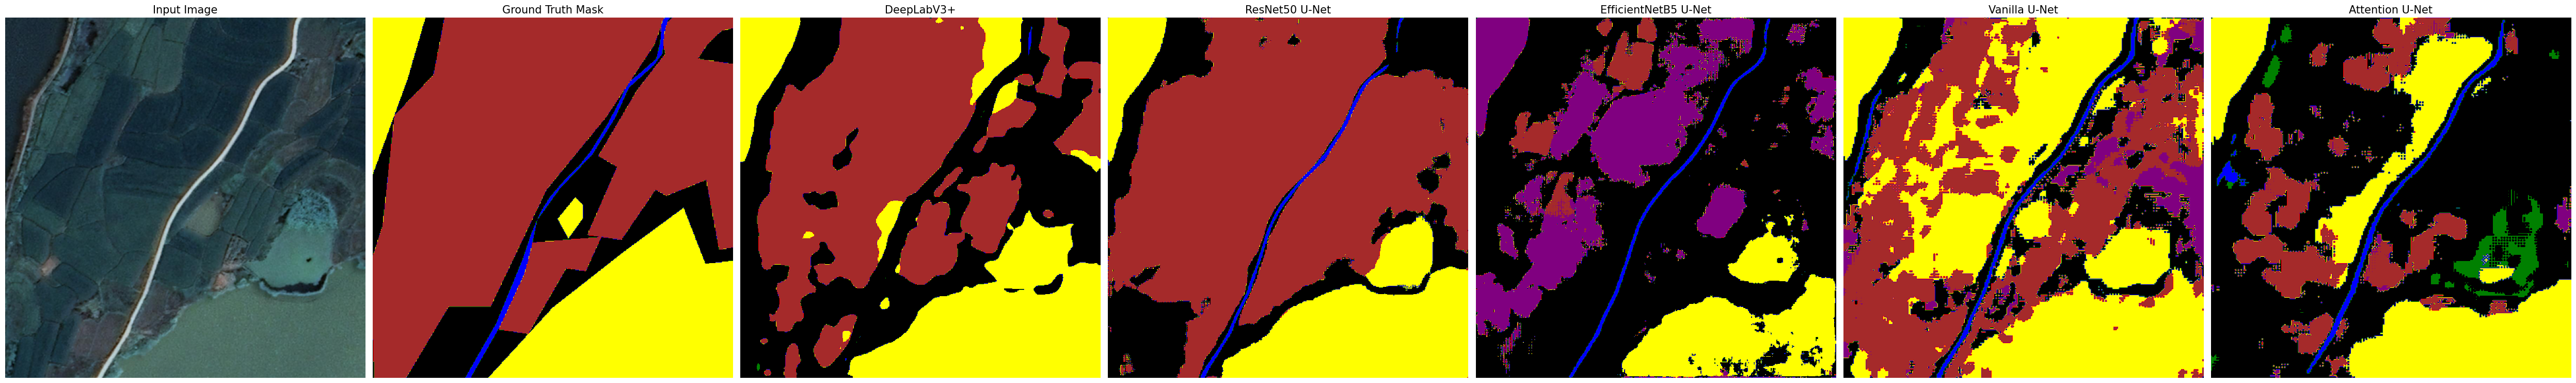

In [ ]:
cmap = ListedColormap(['black', 'green', 'blue', 'yellow', 'red', 'purple', 'brown'])
class_names = ['Background', 'Building', 'Road', 'Water', 'Barren', 'Forest', 'Agriculture']

fig, axes = plt.subplots(1, 7, figsize=(50,25))

idx = 3

# Original Image
axes[0].imshow(reverse_preprocess_input(batch_image[idx]))
axes[0].set_title('Input Image', fontsize=15)
axes[0].axis('off')

# Ground Truth Mask
axes[1].imshow(np.argmax(batch_mask[idx], axis=-1), cmap=cmap, vmin=0, vmax=len(class_names)-1)
axes[1].set_title('Ground Truth Mask', fontsize=15)
axes[1].axis('off')

# DeepLabV3Plus Prediction
pred_deeplab_mask = np.argmax(deeplab_predictions[idx], axis=-1)
axes[2].imshow(pred_deeplab_mask, cmap=cmap, vmin=0, vmax=len(class_names)-1)
axes[2].set_title('DeepLabV3+', fontsize=15)
axes[2].axis('off')

# ResNet50-UNet Prediction
pred_resnet_mask = np.argmax(resnet_unet_predictions[idx], axis=-1)
axes[3].imshow(pred_resnet_mask, cmap=cmap, vmin=0, vmax=len(class_names)-1)
axes[3].set_title('ResNet50 U-Net', fontsize=15)
axes[3].axis('off')

# EfficientNetB0-UNet Prediction
pred_efficientnet_mask = np.argmax(efficientnet_unet_predictions[idx], axis=-1)
axes[4].imshow(pred_efficientnet_mask, cmap=cmap, vmin=0, vmax=len(class_names)-1)
axes[4].set_title('EfficientNetB5 U-Net', fontsize=15)
axes[4].axis('off')

# Vanilla UNet Prediction
pred_vanilla_mask = np.argmax(vanilla_unet_predictions[idx], axis=-1)
axes[5].imshow(pred_vanilla_mask, cmap=cmap, vmin=0, vmax=len(class_names)-1)
axes[5].set_title('Vanilla U-Net', fontsize=15)
axes[5].axis('off')

# Attention UNet Prediction
pred_attention_mask = np.argmax(attention_unet_predictions[idx], axis=-1)
axes[6].imshow(pred_attention_mask, cmap=cmap, vmin=0, vmax=len(class_names)-1)
axes[6].set_title('Attention U-Net', fontsize=15)
axes[6].axis('off')

legend_elements = [
    mpatches.Patch(facecolor='black', edgecolor='black', linewidth=1, label='Background'),
    mpatches.Patch(facecolor='green', edgecolor='black', linewidth=1, label='Building'),
    mpatches.Patch(facecolor='blue', edgecolor='black', linewidth=1, label='Road'),
    mpatches.Patch(facecolor='yellow', edgecolor='black', linewidth=1, label='Water'),
    mpatches.Patch(facecolor='red', edgecolor='black', linewidth=1, label='Barren'),
    mpatches.Patch(facecolor='purple', edgecolor='black', linewidth=1, label='Forest'),
    mpatches.Patch(facecolor='brown', edgecolor='black', linewidth=1, label='Agriculture')
]
#fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.75), ncol=7, fontsize='x-large')

plt.tight_layout()
plt.savefig('image.png')